In [8]:
# Szeregi czasowe - prognoza sprzedaży mebli

#W poniższym projekcie zajmiemy się analizą danych sprzedażowych sklepu Superstore. Naszym głównym celem jest prognozowanie sprzedaży mebli z wykorzystaniem modeli statystycznych (ARIMA) oraz biblioteki Prophet.

#Analiza podzielona jest na etapy:
#1. Przygotowanie i wstępne przetwarzanie danych.
#2. Wizualizacja i dekompozycja szeregu.
#3. Dobór parametrów i modelowanie ARIMA.
#4. Walidacja prognoz.
#5. Porównanie z kategorią Artykuły Biurowe (Office Supplies).
#6. Modelowanie przy użyciu Facebook Prophet.

In [9]:
# Import niezbędnych bibliotek i konfiguracja wykresów
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import matplotlib

# Konfiguracja stylu wykresów na bardziej czytelny
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')

# Ustawienia domyślne wielkości czcionek na wykresach
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

In [10]:
## 1. Wstępne przetwarzanie danych

#Wczytujemy dane z pliku Excel. Zbiór zawiera kilka kategorii, ale na początku skupiamy się wyłącznie na **meblach (Furniture)**.

In [11]:
# Wczytanie danych z pliku Excel
df = pd.read_excel("Superstore.xls")

# Wyfiltrowanie danych tylko dla kategorii 'Furniture'
furniture = df.loc[df['Category'] == 'Furniture']

# Sprawdzenie zakresu czasowego danych (powinny obejmować 4 lata)
print("Początek danych:", furniture['Order Date'].min())
print("Koniec danych:", furniture['Order Date'].max())

Początek danych: 2014-01-06 00:00:00
Koniec danych: 2017-12-30 00:00:00


In [12]:
### Czyszczenie i przygotowanie ramki danych

#Ten krok obejmuje usunięcie zbędnych kolumn, które nie przydadzą się w analizie szeregów czasowych, sprawdzenie czy nie brakuje danych oraz posortowanie wartości chronologicznie.

In [13]:
# Lista kolumn do usunięcia - zostawiamy tylko datę i sprzedaż
cols = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name',
        'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID',
        'Category', 'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit']

furniture.drop(cols, axis=1, inplace=True)
furniture = furniture.sort_values('Order Date')

# Sprawdzenie brakujących wartości (nulli)
print("Liczba brakujących wartości:\n", furniture.isnull().sum())

# Agregacja sprzedaży według daty (sumujemy sprzedaż z każdego dnia)
furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()

# Ustawienie daty jako indeksu ramki danych
furniture = furniture.set_index('Order Date')
print(furniture.index)

Liczba brakujących wartości:
 Order Date    0
Sales         0
dtype: int64
DatetimeIndex(['2014-01-06', '2014-01-07', '2014-01-10', '2014-01-11',
               '2014-01-13', '2014-01-14', '2014-01-16', '2014-01-19',
               '2014-01-20', '2014-01-21',
               ...
               '2017-12-18', '2017-12-19', '2017-12-21', '2017-12-22',
               '2017-12-23', '2017-12-24', '2017-12-25', '2017-12-28',
               '2017-12-29', '2017-12-30'],
              dtype='datetime64[ns]', name='Order Date', length=889, freq=None)


In [14]:
### Resampling danych

#Dane dzienne są zbyt szczegółowe i trudne do analizy ("zaszumione"). Przekształcamy je na **średnie miesięczne** (MS - Month Start), używając początku każdego miesiąca jako znacznika czasu.

In [15]:
# Resampling do średnich miesięcznych
y = furniture['Sales'].resample('MS').mean()

# Szybki podgląd danych z roku 2017
print(y['2017':])

Order Date
2017-01-01     397.602133
2017-02-01     528.179800
2017-03-01     544.672240
2017-04-01     453.297905
2017-05-01     678.302328
2017-06-01     826.460291
2017-07-01     562.524857
2017-08-01     857.881889
2017-09-01    1209.508583
2017-10-01     875.362728
2017-11-01    1277.817759
2017-12-01    1256.298672
Freq: MS, Name: Sales, dtype: float64


In [16]:
## 2. Wizualizacja i dekompozycja

#Rzucamy okiem na wykres sprzedaży w czasie. Szukamy wzorców sezonowości (np. wysoka sprzedaż pod koniec roku) oraz ogólnego trendu.

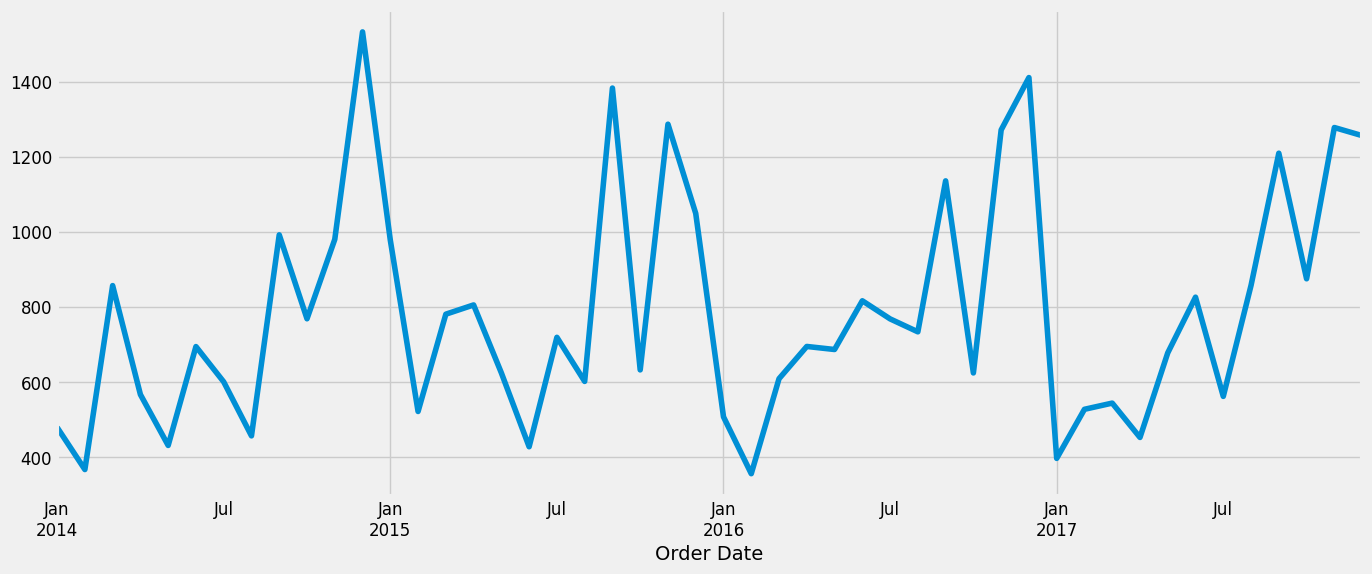

In [17]:
# Wykres liniowy sprzedaży mebli
y.plot(figsize=(15, 6))
plt.show()

In [18]:
### Dekompozycja szeregu czasowego

#Używamy metody dekompozycji, aby rozbić nasz szereg na trzy składowe:
#1. **Trend** (kierunek zmian w długim okresie).
#2. **Sezonowość** (powtarzalne wzorce cykliczne).
#3. **Szum** (reszty, przypadkowe wahania).

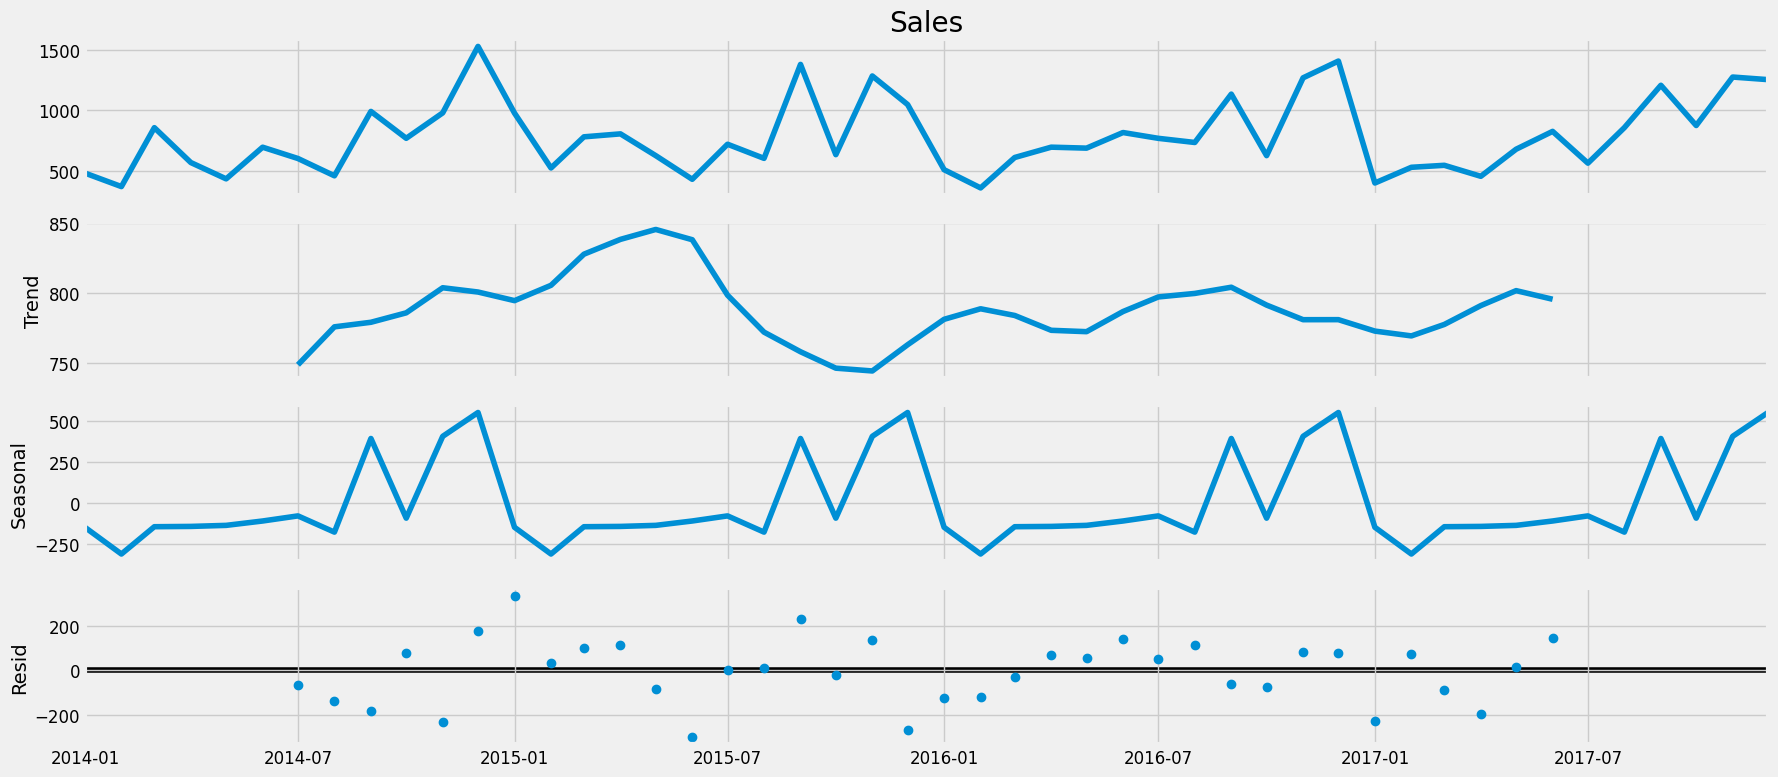

In [19]:
from pylab import rcParams
rcParams['figure.figsize'] = 18, 8

# Dekompozycja addytywna
decomposition = sm.tsa.seasonal_decompose(y, model='additive')
fig = decomposition.plot()
plt.show()

In [20]:
## 3. Prognozowanie modelem ARIMA

#Zastosujemy model **ARIMA** (AutoRegressive Integrated Moving Average). Parametry modelu oznaczane są jako `(p, d, q)`. Naszym celem jest znalezienie optymalnej kombinacji tych parametrów, która da najniższą wartość **AIC** (Kryterium Informacyjne Akaike).

In [21]:
# Definiowanie zakresu parametrów p, d, q (0 lub 1)
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

print('Przykłady kombinacji parametrów dla Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Przykłady kombinacji parametrów dla Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


In [22]:
### Grid Search (Wyszukiwanie siatki)

#Uruchamiamy pętlę, która przetestuje różne kombinacje parametrów i wypisze ich wynik AIC. Szukamy najniższej wartości.

In [23]:
# Pętla szukająca najlepszego modelu (najniższe AIC)
min_aic = float('inf')
best_param = None
best_seasonal_param = None

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(y,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit()
            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))

            # Zapiszmy najlepszy wynik (zgodnie z poleceniem znalezienia wartości)
            if results.aic < min_aic:
                min_aic = results.aic
                best_param = param
                best_seasonal_param = param_seasonal
        except:
            continue

print(f"\nNajlepszy model: ARIMA{best_param}x{best_seasonal_param}12 z AIC: {min_aic}")

ARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:769.0817523205915
ARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:1523.5085449297978
ARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:477.7170130919703
ARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:302.27028997936094
ARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:497.2314433418338
ARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:1317.1698862853953
ARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:318.0047199116341
ARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:304.24882803039566
ARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:720.9252270758114
ARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:2715.646290524748
ARIMA(0, 0, 1)x(0, 1, 0, 12)12 - AIC:466.56074298091517
ARIMA(0, 0, 1)x(0, 1, 1, 12)12 - AIC:291.6261389673291
ARIMA(0, 0, 1)x(1, 0, 0, 12)12 - AIC:499.61094365783896
ARIMA(0, 0, 1)x(1, 0, 1, 12)12 - AIC:2488.9411051401207
ARIMA(0, 0, 1)x(1, 1, 0, 12)12 - AIC:319.98848769468657
ARIMA(0, 0, 1)x(1, 1, 1, 12)12 - AIC:291.87255765424135
ARIMA(0, 1, 0)x(0, 0, 0, 12)12 - AIC:677.8947668259312
ARIMA(0, 1, 0)x(0, 0, 1, 12)12 - AIC:1362.3338317546836


In [24]:
### Dopasowanie wybranego modelu

#Na podstawie powyższych wyników (lub sugestii z prezentacji) wybieramy model `SARIMAX(1, 1, 1)x(1, 1, 0, 12)` i przeprowadzamy jego diagnostykę.

In [25]:
# Trenowanie modelu z optymalnymi parametrami
mod = sm.tsa.statespace.SARIMAX(y,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 0, 12),
                                enforce_invertibility=False)
results = mod.fit()
print(results.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0676      0.226      0.299      0.765      -0.376       0.511
ma.L1         -1.0000      0.279     -3.590      0.000      -1.546      -0.454
ar.S.L12      -0.4807      0.147     -3.260      0.001      -0.770      -0.192
sigma2      4.108e+04   6.78e-06   6.06e+09      0.000    4.11e+04    4.11e+04


In [26]:
### Diagnostyka modelu

#Sprawdzamy wykresy diagnostyczne, aby upewnić się, że reszty (błędy) modelu zachowują się prawidłowo (mają rozkład zbliżony do normalnego i brak wyraźnych korelacji).

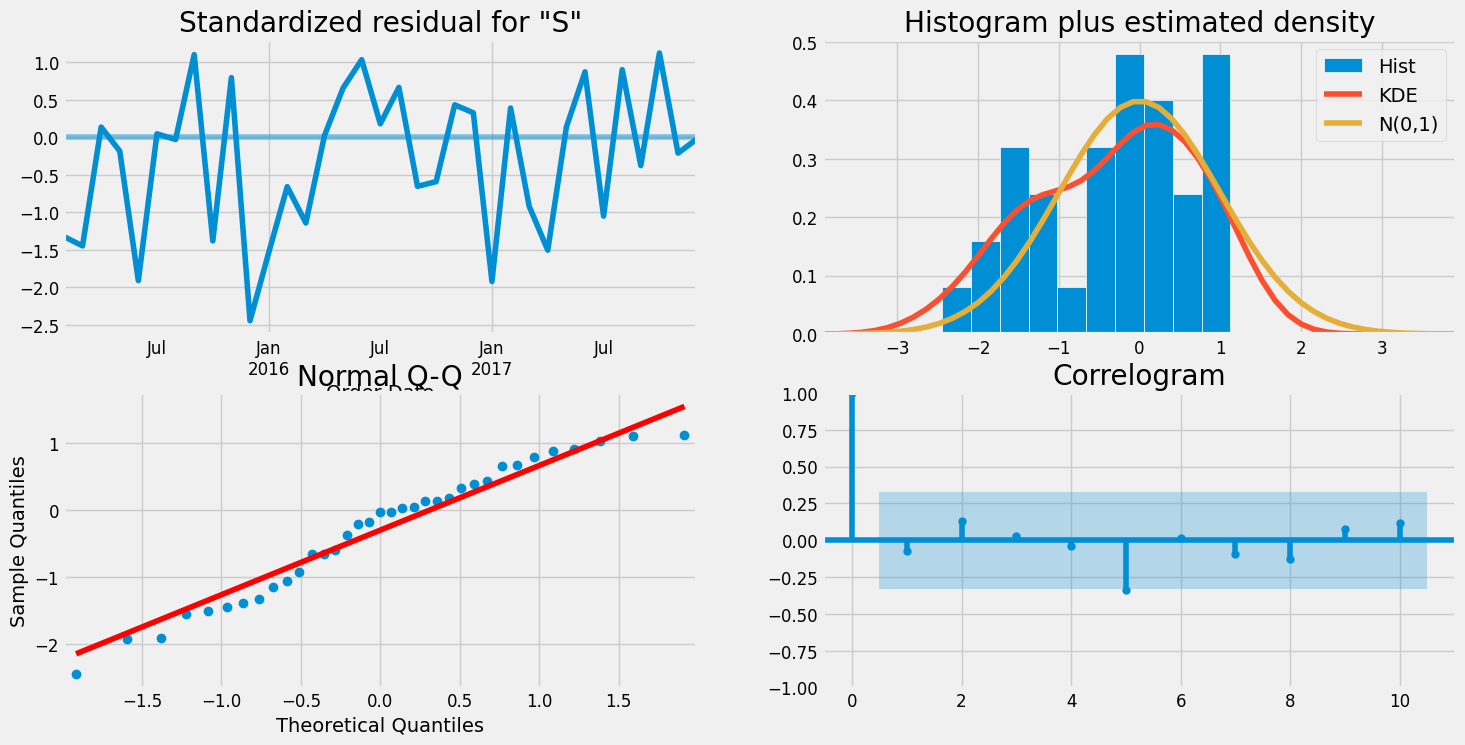

In [27]:
results.plot_diagnostics(figsize=(16, 8))
plt.show()

In [28]:
## 4. Weryfikacja prognoz

#Porównamy prognozy modelu z rzeczywistymi danymi, zaczynając od 2017 roku. Pozwoli to ocenić jakość modelu.

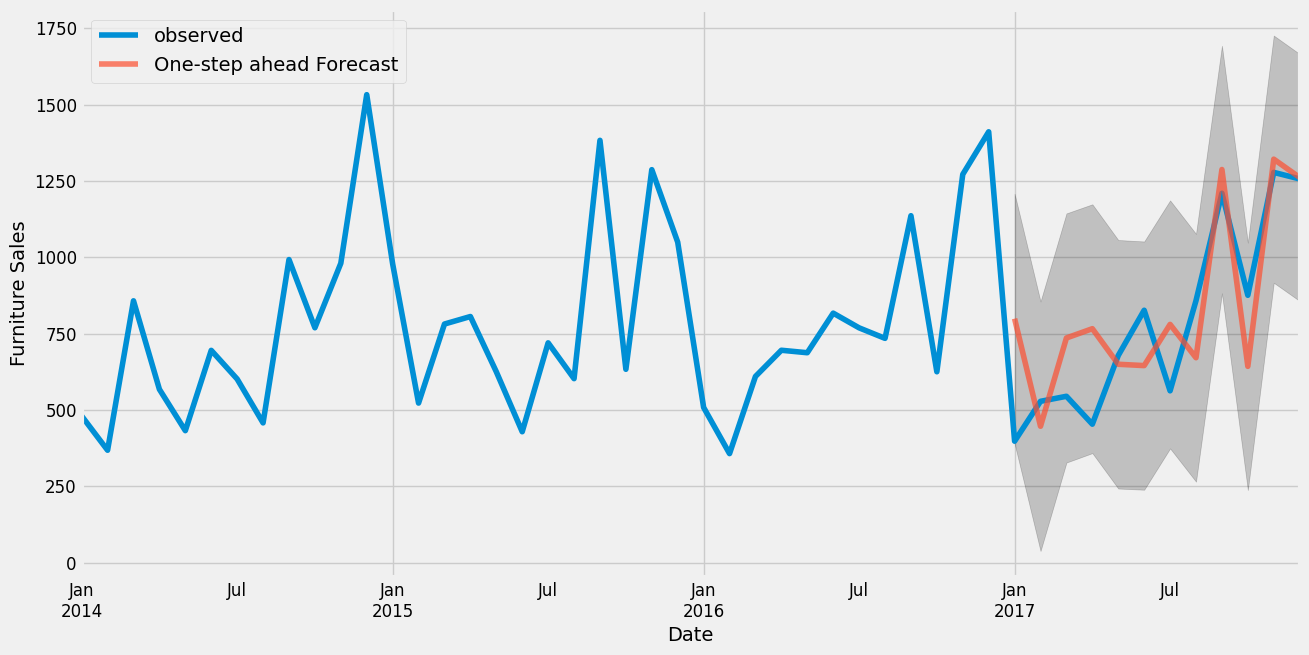

In [29]:
# Generowanie prognozy od 2017-01-01
pred = results.get_prediction(start=pd.to_datetime('2017-01-01'), dynamic=False)
pred_ci = pred.conf_int()

# Wizualizacja: dane obserwowane vs prognoza
ax = y['2014':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 7))

# Zaznaczenie przedziału ufności (szary obszar)
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()

In [30]:
### Miary błędów (MSE i RMSE)

#Obliczamy Średni Błąd Kwadratowy (MSE) oraz Pierwiastek Błędu Średniokwadratowego (RMSE), aby liczbowo ocenić, jak bardzo myli się nasz model.

In [31]:
y_forecasted = pred.predicted_mean
y_truth = y['2017-01-01':]

# Obliczenie MSE
mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

# Obliczenie RMSE
print('The Root Mean Squared Error of our forecasts is {}'.format(round(np.sqrt(mse), 2)))

The Mean Squared Error of our forecasts is 39996.01
The Root Mean Squared Error of our forecasts is 199.99


In [32]:
### Prognoza przyszłości

#Ponieważ model działa poprawnie, generujemy prognozę na kolejne kroki (przyszłość), wykraczającą poza posiadane dane.

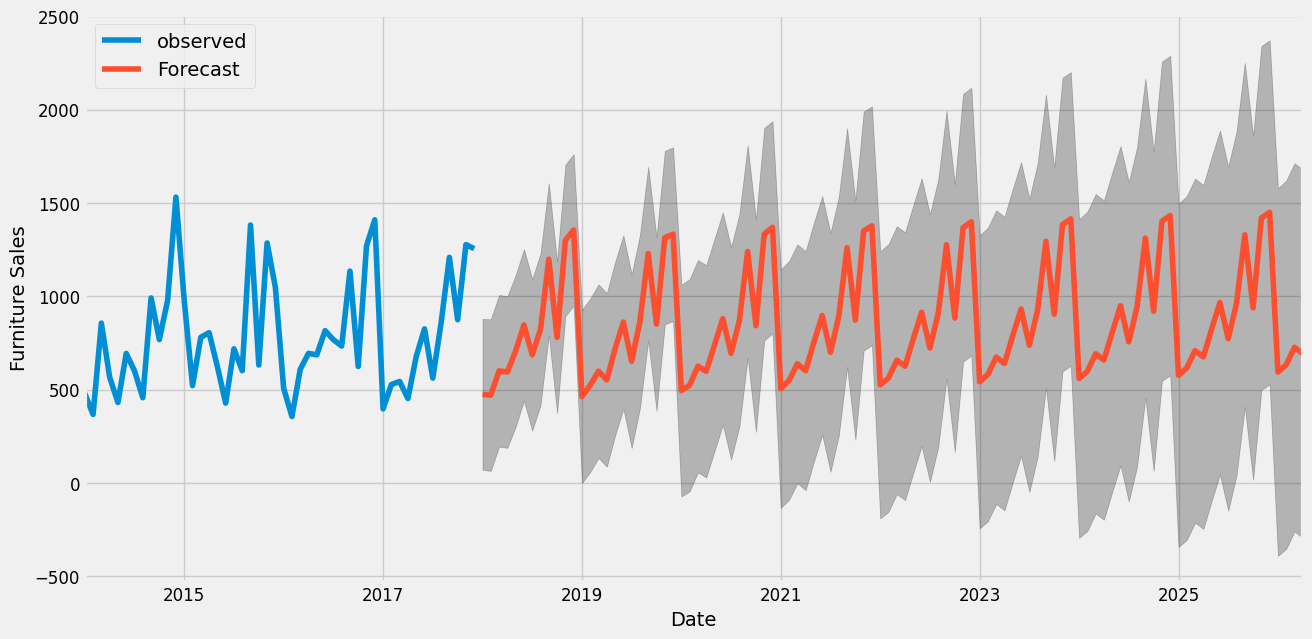

In [33]:
# Prognoza na 100 kroków do przodu
pred_uc = results.get_forecast(steps=100)
pred_ci = pred_uc.conf_int()

ax = y.plot(label='observed', figsize=(14, 7))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')

plt.legend()
plt.show()

In [34]:
## 5. Porównanie: Meble vs Artykuły Biurowe

#Analiza samych mebli to za mało. Porównajmy ich sprzedaż z kategorią **Office Supplies**. Musimy przygotować dane dla tej drugiej kategorii w identyczny sposób.

In [35]:
# Ponowne przygotowanie danych dla obu kategorii
furniture = df.loc[df['Category'] == 'Furniture']
office = df.loc[df['Category'] == 'Office Supplies']

# Usuwanie kolumn i sortowanie (identycznie jak wcześniej)
cols = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name',
        'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID',
        'Category', 'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit']
furniture.drop(cols, axis=1, inplace=True)
office.drop(cols, axis=1, inplace=True)

furniture = furniture.sort_values('Order Date')
office = office.sort_values('Order Date')

furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()
office = office.groupby('Order Date')['Sales'].sum().reset_index()

furniture = furniture.set_index('Order Date')
office = office.set_index('Order Date')

# Resampling miesięczny
y_furniture = furniture['Sales'].resample('MS').mean()
y_office = office['Sales'].resample('MS').mean()

# Połączenie w jedną ramkę danych dla łatwiejszego porównania
furniture = pd.DataFrame({'Order Date': y_furniture.index, 'Sales': y_furniture.values})
office = pd.DataFrame({'Order Date': y_office.index, 'Sales': y_office.values})

store = furniture.merge(office, how='inner', on='Order Date')
store.rename(columns={'Sales_x': 'furniture_sales', 'Sales_y': 'office_sales'}, inplace=True)
store.head()

,Order Date,furniture_sales,office_sales
0,2014-01-01,480.194231,285.357647
1,2014-02-01,367.931600,63.042588
2,2014-03-01,857.291529,391.176318
3,2014-04-01,567.488357,464.794750
4,2014-05-01,432.049188,324.346545


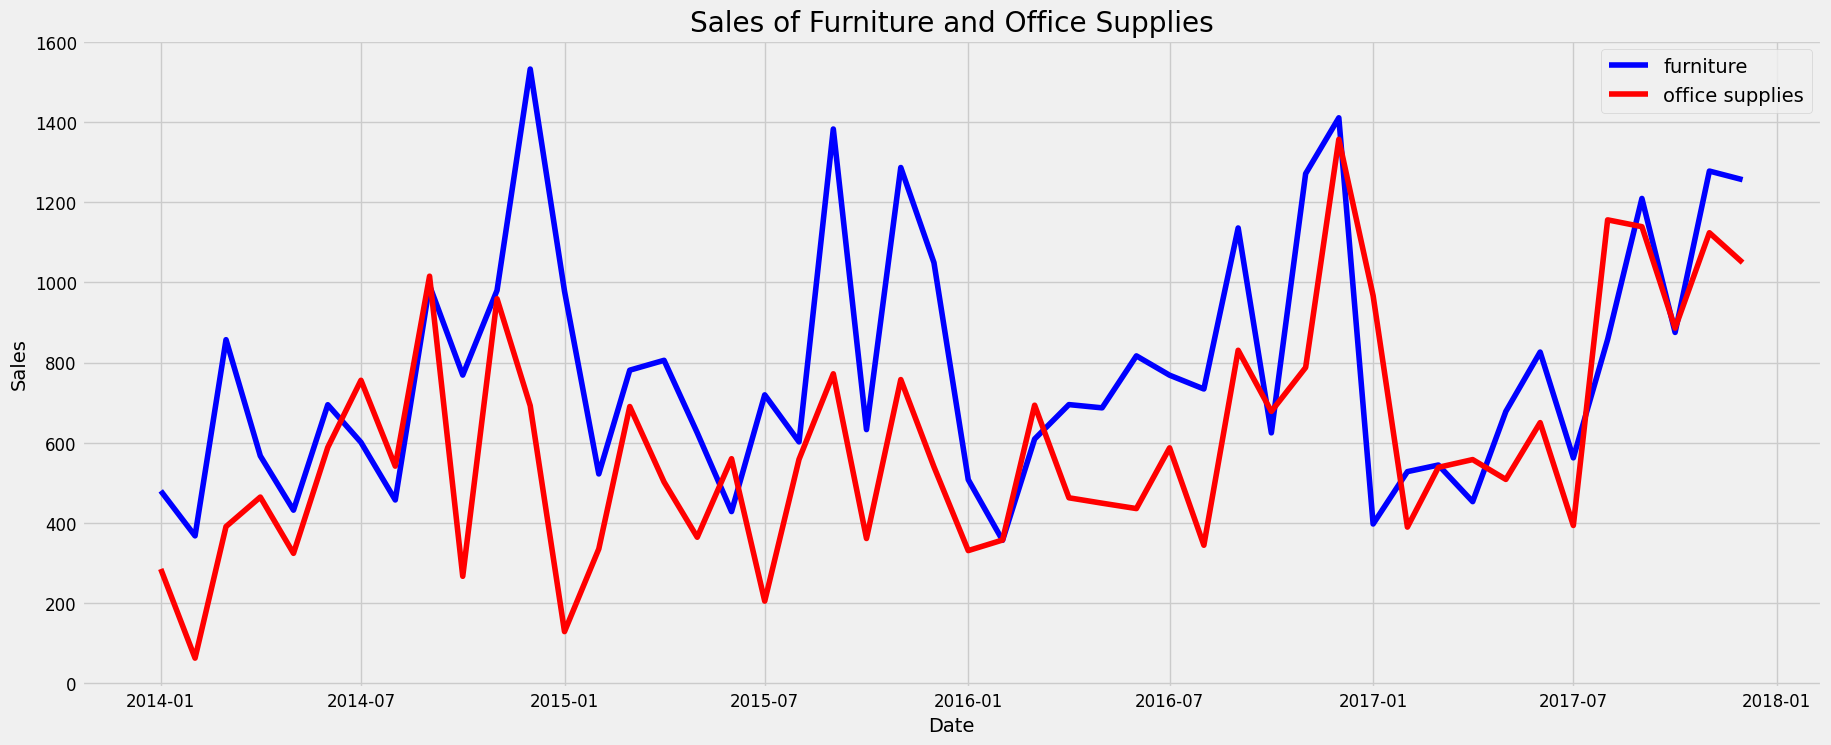

In [36]:
# Wspólny wykres dla obu kategorii
plt.figure(figsize=(20, 8))
plt.plot(store['Order Date'], store['furniture_sales'], 'b-', label = 'furniture')
plt.plot(store['Order Date'], store['office_sales'], 'r-', label = 'office supplies')
plt.xlabel('Date'); plt.ylabel('Sales'); plt.title('Sales of Furniture and Office Supplies')
plt.legend();
plt.show()

In [37]:
### Kiedy biuro przegoniło meble?

#Szukamy pierwszego momentu w czasie, kiedy sprzedaż artykułów biurowych była wyższa niż sprzedaż mebli.

In [38]:
first_date = store.loc[np.min(list(np.where(store['office_sales'] > store['furniture_sales'])[0])), 'Order Date']
print("Office supplies first time produced higher sales than furniture is {}.".format(first_date.date()))

Office supplies first time produced higher sales than furniture is 2014-07-01.


In [39]:
## 6. Modelowanie z Prophet

#Na koniec użyjemy biblioteki **Prophet** (stworzonej przez Facebooka), która świetnie radzi sobie z sezonowością.

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


<Figure size 1800x600 with 0 Axes>

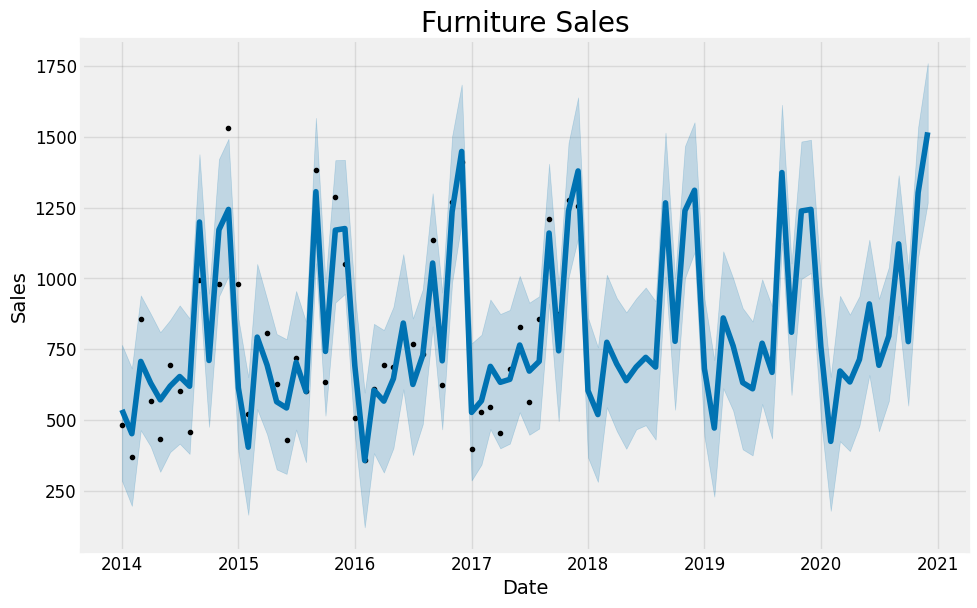

<Figure size 1800x600 with 0 Axes>

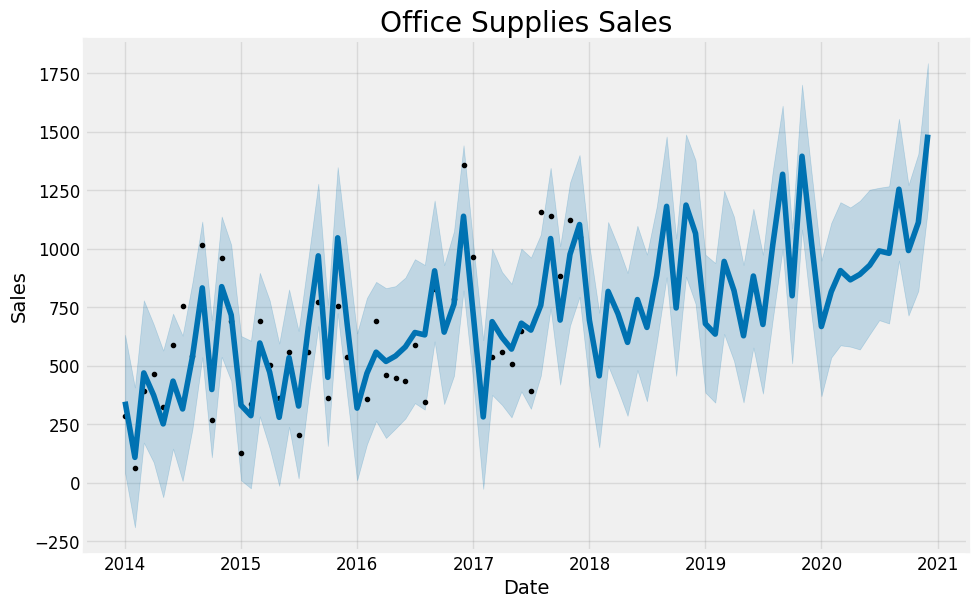

In [40]:
# Import Propheta (dostosowany do starszej składni z prezentacji)
try:
    from fbprophet import Prophet
except ImportError:
    from prophet import Prophet

# Prophet wymaga specyficznych nazw kolumn: 'ds' dla daty i 'y' dla wartości
furniture = furniture.rename(columns={'Order Date': 'ds', 'Sales': 'y'})
furniture_model = Prophet(interval_width=0.95)
furniture_model.fit(furniture)

office = office.rename(columns={'Order Date': 'ds', 'Sales': 'y'})
office_model = Prophet(interval_width=0.95)
office_model.fit(office)

# Tworzenie ramki na przyszłe daty (36 miesięcy do przodu)
furniture_forecast = furniture_model.make_future_dataframe(periods=36, freq='MS')
furniture_forecast = furniture_model.predict(furniture_forecast)

office_forecast = office_model.make_future_dataframe(periods=36, freq='MS')
office_forecast = office_model.predict(office_forecast)

# Wizualizacja prognozy dla mebli
plt.figure(figsize=(18, 6))
furniture_model.plot(furniture_forecast, xlabel = 'Date', ylabel = 'Sales')
plt.title('Furniture Sales');
plt.show()

# Wizualizacja prognozy dla artykułów biurowych
plt.figure(figsize=(18, 6))
office_model.plot(office_forecast, xlabel = 'Date', ylabel = 'Sales')
plt.title('Office Supplies Sales');
plt.show()

In [41]:
### Porównanie trendów (Prophet)

#Łączymy prognozy z Propheta, aby zobaczyć czyste trendy obu kategorii na jednym wykresie.

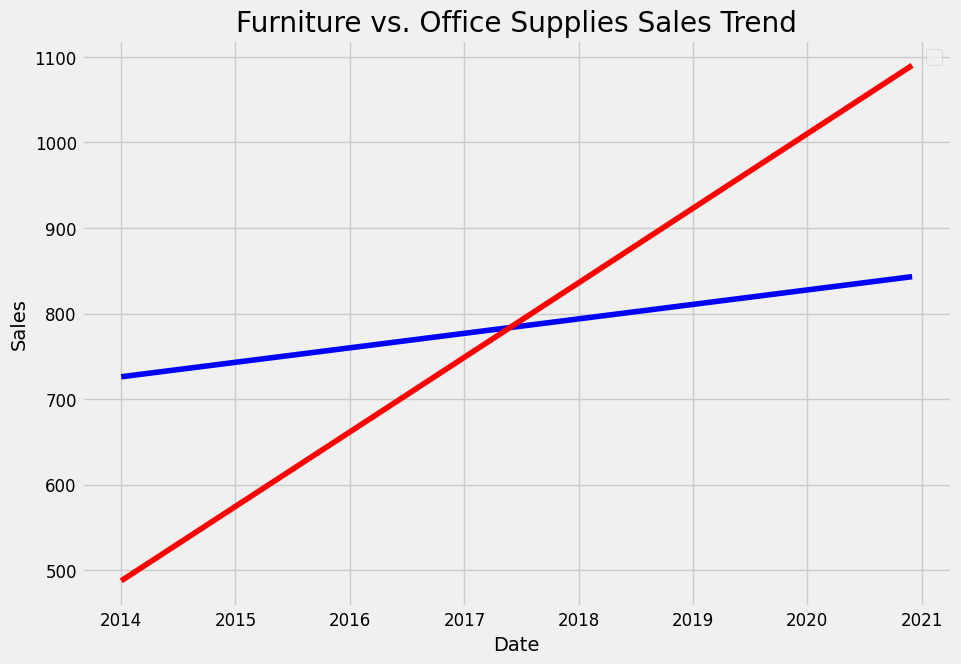

In [42]:
# Przygotowanie nazw kolumn do połączenia
furniture_names = ['furniture_%s' % column for column in furniture_forecast.columns]
office_names = ['office_%s' % column for column in office_forecast.columns]

merge_furniture_forecast = furniture_forecast.copy()
merge_office_forecast = office_forecast.copy()

merge_furniture_forecast.columns = furniture_names
merge_office_forecast.columns = office_names

# Łączenie prognoz
forecast = pd.merge(merge_furniture_forecast, merge_office_forecast, how='inner', left_on='furniture_ds', right_on='office_ds')
forecast = forecast.rename(columns={'furniture_ds': 'Date'}).drop('office_ds', axis=1)

# Wykres trendów
plt.figure(figsize=(10, 7))
plt.plot(forecast['Date'], forecast['furniture_trend'], 'b-')
plt.plot(forecast['Date'], forecast['office_trend'], 'r-')
plt.legend(); plt.xlabel('Date'); plt.ylabel('Sales')
plt.title('Furniture vs. Office Supplies Sales Trend');
plt.show()

In [43]:
### Komponenty modelu (Sezonowość)

#Na koniec analizujemy składowe modelu, aby zobaczyć, które miesiące są najlepsze, a które najgorsze dla każdej kategorii.

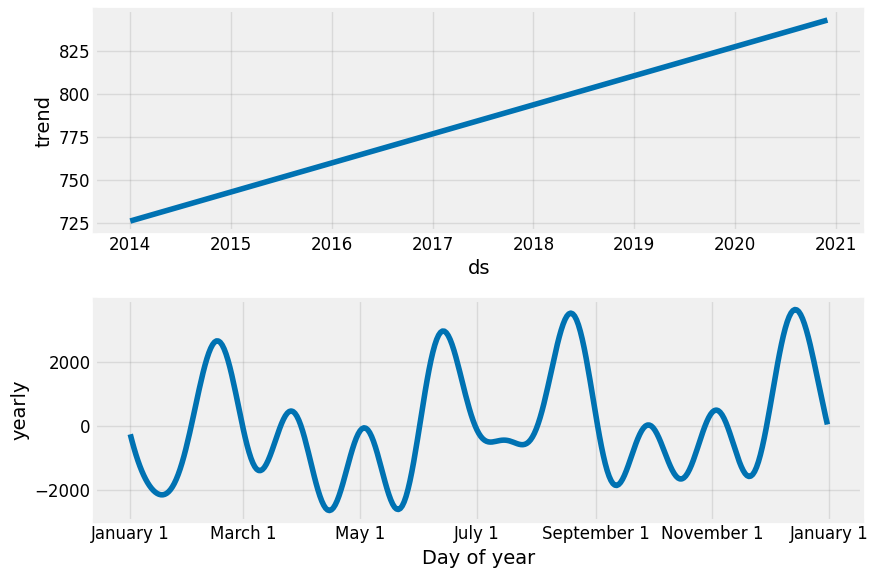

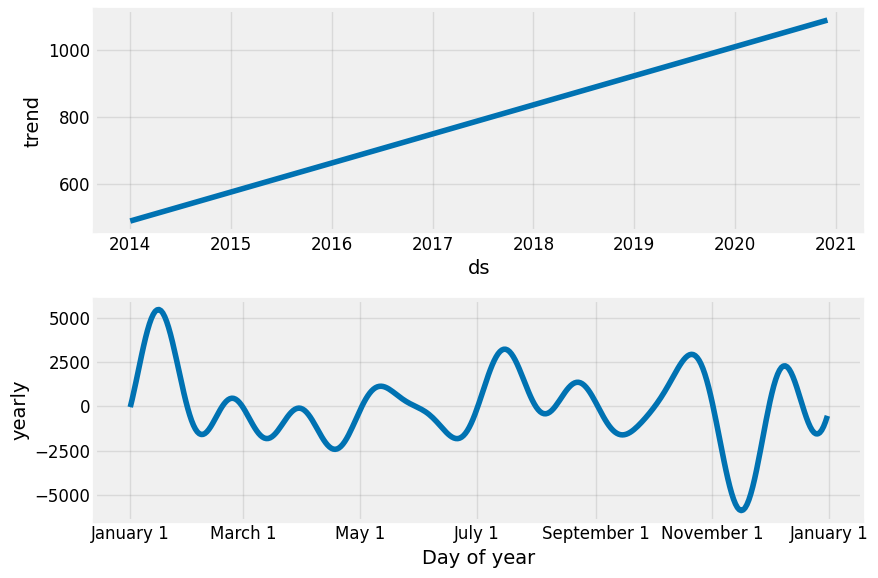

In [44]:
# Komponenty dla mebli
furniture_model.plot_components(furniture_forecast);

# Komponenty dla artykułów biurowych
office_model.plot_components(office_forecast);